In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq

import matplotlib.colors as mcolors


/home/msoledad/.conda/envs/spatial/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/msoledad/.local/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [3]:
#CAREFUL WITH THE SYMLINK TO RAWDATA<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-<-
flat_file_dir = '/home/msoledad/cosmx/testImage/'
meta_file = [item for item in os.listdir(flat_file_dir) if 'meta' in item][0]
counts_file = [item for item in os.listdir(flat_file_dir) if 'expre' in item][0]
fov_file = [item for item in os.listdir(flat_file_dir) if 'pos_' in item][0]

adata = sq.read.nanostring(
    path=flat_file_dir,
    counts_file=counts_file,
    meta_file=meta_file,
    fov_file=fov_file
)

In [4]:
adata.obs["fov"]

1105_406    406
236_406     406
1274_406    406
15_406      406
1538_406    406
           ... 
995_177     177
996_177     177
997_177     177
998_177     177
999_177     177
Name: fov, Length: 3965, dtype: category
Categories (2, object): ['177', '406']

In [5]:
adata = adata.copy()

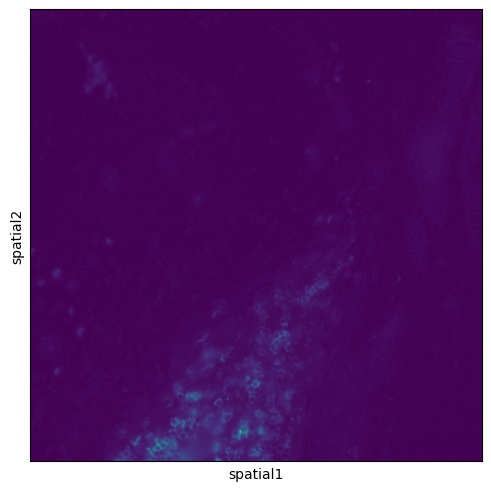

In [5]:
sq.pl.spatial_scatter(adata, library_key="cell_ID",img_channel=2,library_id=['368'])

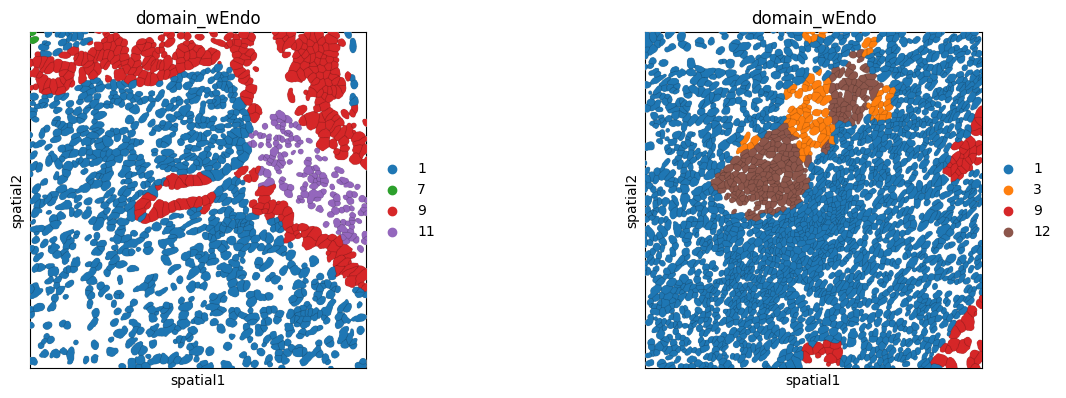

In [6]:
adata.obs["domain_wEndo"]= pd.Categorical(adata.obs["domain_wEndo"])

sq.pl.spatial_segment(
    adata,
    color="domain_wEndo",
    library_key="fov",
    library_id=["177","406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    #palette=custom_cmap,
    na_color="white"
)

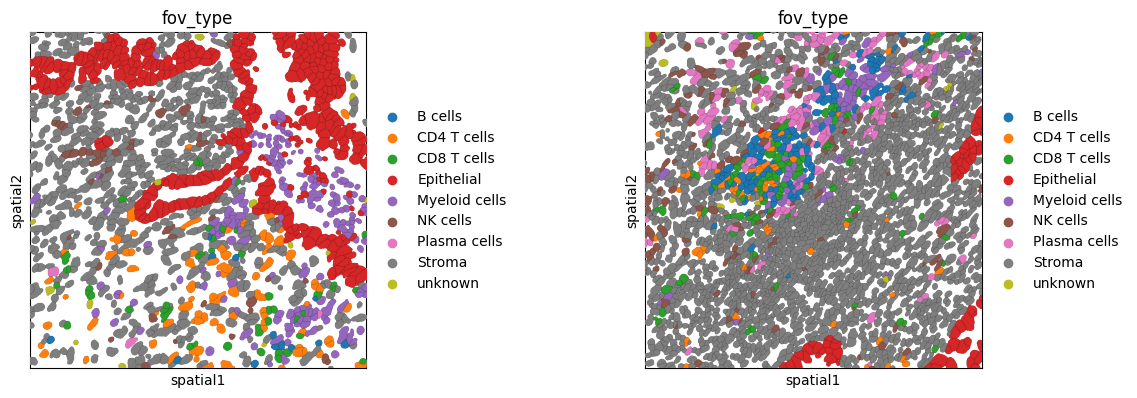

In [13]:
sq.pl.spatial_segment(
    adata,
    color="fov_type",
    library_key="fov",
    library_id=["177","406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    na_color="white"
)

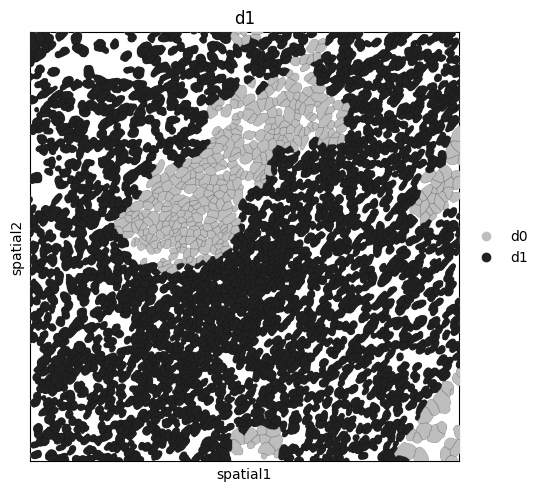

In [7]:
domcols = {
    "0": "#bebebe",
    "1": "#212121",#black
    "9": "#eec900",#gold
    "11": "#8B668B",#plum
    "12": "#b03060",
}
sq.pl.spatial_segment(
    adata,
    color="d1",
    library_key="fov",
    library_id=["406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([domcols[label] for label in ['0','1']]),
    frameon=True,
)
plt.savefig("testImage/2314A11_fov406d1.svg", dpi=200)

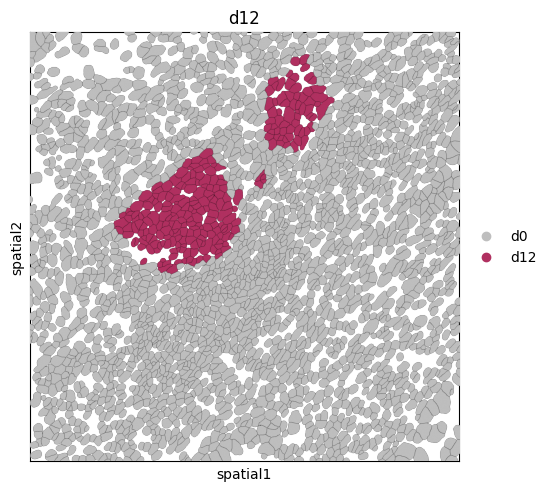

In [8]:
sq.pl.spatial_segment(
    adata,
    color="d12",
    library_key="fov",
    library_id=["406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([domcols[label] for label in ['0','12']]),
    frameon=True,
)
plt.savefig("testImage/2314A11_fov406d12.svg", dpi=200)

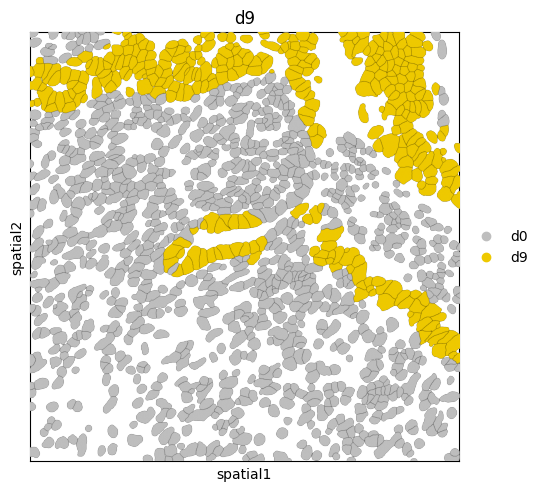

In [9]:
sq.pl.spatial_segment(
    adata,
    color="d9",
    library_key="fov",
    library_id=["177"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([domcols[label] for label in ['0','9']]),
    frameon=True,
)
plt.savefig("testImage/2314A11_fov177d9.svg", dpi=200)

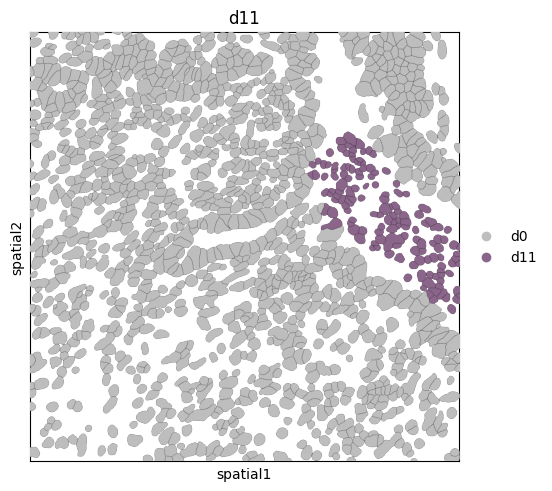

In [10]:
sq.pl.spatial_segment(
    adata,
    color="d11",
    library_key="fov",
    library_id=["177"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([domcols[label] for label in ['0','11']]),
    frameon=True,
)
plt.savefig("testImage/2314A11_fov177d11.svg", dpi=200)

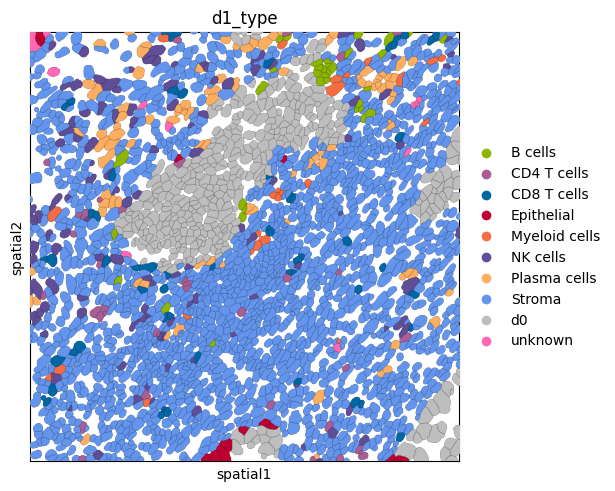

In [24]:
cellcols = {
    "d0": "#bebebe",
    "B cells": "#8DB600",
    "CD4 T cells": "#a95f96",
    "CD8 T cells": "#0067A5",
    "Epithelial": "#BE0032",
    "Myeloid cells": "#f46d43",
    "NK cells":"#604E97",
    "Plasma cells":"#fdae61",
    "Stroma":"#6495ed",
    "unknown":"#ff69b4"
}

adata.obs["d1_type"]= pd.Categorical(adata.obs["d1_type"])
#adata.obs["d1_type"] = adata.obs["d1_type"].astype("category")
#adata.obs["d1_type"].cat.set_categories(['B','t4','t8','ep','my','nk','s','d0','p','u'])
sq.pl.spatial_segment(
    adata,
    color="d1_type",
    library_key="fov",
    library_id=["406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([cellcols[label] for label in adata.obs["d1_type"].cat.categories]),
    frameon=True,
)
plt.savefig("testImage/2314A11_fov406d1ct.svg", dpi=200)



In [28]:
#adata.obs["d2_type"]= pd.Categorical(adata.obs["d2_type"])
adata.obs["d12_type"].cat.categories

Index(['B cells', 'CD4 T cells', 'CD8 T cells', 'Myeloid cells', 'NK cells',
       'Plasma cells', 'Stroma', 'd0', 'unknown'],
      dtype='object')

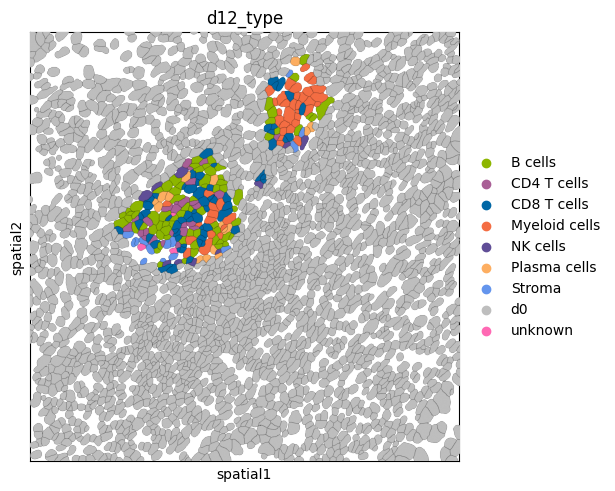

In [29]:
sq.pl.spatial_segment(
    adata,
    color="d12_type",
    library_key="fov",
    library_id=["406"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([cellcols[label] for label in adata.obs["d12_type"].cat.categories]),
)
plt.savefig("testImage/2314A11_fov406d12ct.svg", dpi=200)

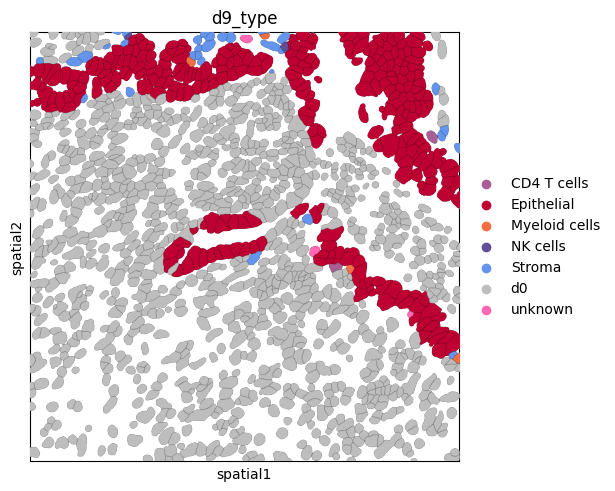

In [30]:
sq.pl.spatial_segment(
    adata,
    color="d9_type",
    library_key="fov",
    library_id=["177"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([cellcols[label] for label in adata.obs["d9_type"].cat.categories]),
)
plt.savefig("testImage/2314A11_fov177d9ct.svg", dpi=200)

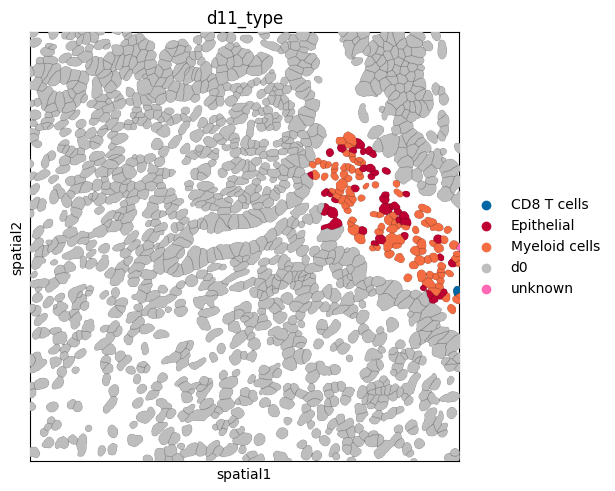

In [31]:
sq.pl.spatial_segment(
    adata,
    color="d11_type",
    library_key="fov",
    library_id=["177"],
    seg_cell_id="cell_ID",
    img_alpha=0,
    seg_outline=True,
    img_channel=0,
    palette=mcolors.ListedColormap([cellcols[label] for label in adata.obs["d11_type"].cat.categories]),
)
plt.savefig("testImage/2314A11_fov177d11ct.svg", dpi=200)

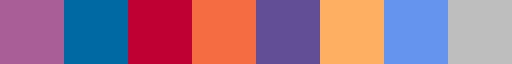

In [49]:
mcolors.ListedColormap([cellcols[label] for label in ['t4','t8','ep','my','nk','p','s','d0']])

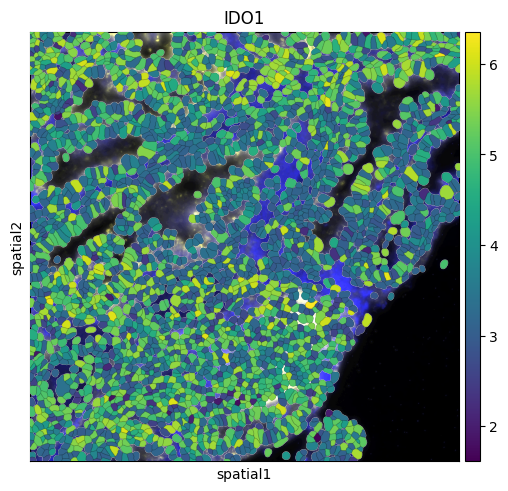

In [6]:

sq.pl.spatial_segment(
    adata,
    color="IDO1",
    library_key="fov",
    library_id=["465"],
    seg_contourpx=10,
    seg_cell_id="cell_ID",
    seg_outline=True,

)
